# Análise de Dados - Sem Falha (No Ground Truth)
## carbonZ_2018-07-18-12-10-11_no_ground_truth

Análise completa dos dados de telemetria e sensores - Voo sem falha conhecida.

In [2]:
# 1. IMPORT REQUIRED LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Path da pasta com os dados - PASTA ATUALIZADA
data_path = r'c:\Users\vfide\Desktop\ProjetoIA\processed\carbonZ_2018-07-18-12-10-11_no_ground_truth'
print(f"Carregando dados de: {data_path}")

Carregando dados de: c:\Users\vfide\Desktop\ProjetoIA\processed\carbonZ_2018-07-18-15-53-31_1_engine_failure


## 2. Carregar e Explorar Dados

In [4]:
import os
import glob

# Listar arquivos CSV disponíveis
csv_files = sorted(glob.glob(os.path.join(data_path, '*.csv')))
print(f"Total de arquivos CSV: {len(csv_files)}\n")

# Selecionar apenas os arquivos da 8ª até 18ª posição (índices 7 a 17)
selected_csv_files = csv_files[7:18]
print(f"Carregando arquivos da 8ª até 18ª posição:\n")

for i, file in enumerate(selected_csv_files, 8):
    print(f"{i}. {os.path.basename(file)}")

# Carregar os arquivos selecionados
datasets_dict = {}
for file_path in selected_csv_files:
    file_name = os.path.basename(file_path).replace('carbonZ_2018-07-18-15-53-31_1_engine_failure-', '').replace('.csv', '')
    try:
        datasets_dict[file_name] = pd.read_csv(file_path)
        print(f"✓ Carregado: {file_name}")
    except Exception as e:
        print(f"✗ Erro ao carregar {file_name}: {e}")

print(f"\n✓ {len(datasets_dict)} arquivos carregados com sucesso!")

Total de arquivos CSV: 34

Carregando arquivos da 8ª até 18ª posição:

8. carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-global.csv
9. carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-local.csv
10. carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-raw-fix.csv
11. carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-raw-gps_vel.csv
12. carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-rel_alt.csv
13. carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-atm_pressure.csv
14. carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-data.csv
15. carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-data_raw.csv
16. carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-mag.csv
17. carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-temperature.csv
18. carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-local_position-odom.csv
✓ Carregado: mavros-global_position-global
✓ Carregado: mavros-glob

In [5]:
# Explorar informações dos dados
print("=" * 70)
print("INFORMAÇÕES DOS ARQUIVOS CARREGADOS (8ª a 18ª CSV)")
print("=" * 70)

for name, df in datasets_dict.items():
    print(f"\n{name}:")
    print(f"  Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas")
    print(f"  Colunas: {list(df.columns)[:5]}{'...' if len(df.columns) > 5 else ''}")
    print(f"  Tipos: {df.dtypes.unique()}")
    print(f"  Amostra (primeiras 2 linhas):")
    print(df.head(2).to_string())

INFORMAÇÕES DOS ARQUIVOS CARREGADOS (8ª a 18ª CSV)

mavros-global_position-global:
  Dimensões: 544 linhas × 19 colunas
  Colunas: ['%time', 'field.header.seq', 'field.header.stamp', 'field.header.frame_id', 'field.status.status']...
  Tipos: [dtype('int64') <StringDtype(storage='python', na_value=nan)>
 dtype('float64')]
  Amostra (primeiras 2 linhas):
                 %time  field.header.seq   field.header.stamp field.header.frame_id  field.status.status  field.status.service  field.latitude  field.longitude  field.altitude  field.position_covariance0  field.position_covariance1  field.position_covariance2  field.position_covariance3  field.position_covariance4  field.position_covariance5  field.position_covariance6  field.position_covariance7  field.position_covariance8  field.position_covariance_type
0  1531943810885613340               981  1531943810884418155             base_link                    0                     1       40.591458       -79.899496      345.772221         

## 3. Limpeza e Processamento de Dados

In [6]:
# Tratamento de valores faltantes
print("Verificando valores faltantes...\n")
for name, df in datasets_dict.items():
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f"{name}:")
        print(missing[missing > 0])
        # Preencher valores faltantes com forward fill
        df.fillna(method='ffill', inplace=True)
    else:
        print(f"{name}: ✓ Sem valores faltantes")

# Converter timestamp se existir
for name, df in datasets_dict.items():
    timestamp_cols = [col for col in df.columns if 'time' in col.lower()]
    for col in timestamp_cols:
        try:
            df[col] = pd.to_datetime(df[col])
        except:
            pass

print("\n✓ Limpeza e processamento concluído!")

Verificando valores faltantes...

mavros-global_position-global: ✓ Sem valores faltantes
mavros-global_position-local: ✓ Sem valores faltantes
mavros-global_position-raw-fix: ✓ Sem valores faltantes
mavros-global_position-raw-gps_vel: ✓ Sem valores faltantes
mavros-global_position-rel_alt: ✓ Sem valores faltantes
mavros-imu-atm_pressure: ✓ Sem valores faltantes
mavros-imu-data: ✓ Sem valores faltantes
mavros-imu-data_raw: ✓ Sem valores faltantes
mavros-imu-mag: ✓ Sem valores faltantes
mavros-imu-temperature: ✓ Sem valores faltantes
mavros-local_position-odom: ✓ Sem valores faltantes

✓ Limpeza e processamento concluído!


## 4. Estatísticas Descritivas

In [7]:
# Estatísticas Descritivas
print("=" * 70)
print("ESTATÍSTICAS DESCRITIVAS (8ª a 18ª CSV)")
print("=" * 70)

for name, df in datasets_dict.items():
    numeric_df = df.select_dtypes(include=[np.number])
    if not numeric_df.empty:
        print(f"\n{name}:")
        print(numeric_df.describe().round(4))
    else:
        print(f"\n{name}: Sem colunas numéricas")

ESTATÍSTICAS DESCRITIVAS (8ª a 18ª CSV)

mavros-global_position-global:
       field.header.seq  field.header.stamp  field.status.status  \
count          544.0000        5.440000e+02                544.0   
mean          1252.5000        1.531944e+18                  0.0   
std            157.1835        3.827495e+10                  0.0   
min            981.0000        1.531944e+18                  0.0   
25%           1116.7500        1.531944e+18                  0.0   
50%           1252.5000        1.531944e+18                  0.0   
75%           1388.2500        1.531944e+18                  0.0   
max           1524.0000        1.531944e+18                  0.0   

       field.status.service  field.latitude  field.longitude  field.altitude  \
count                 544.0        544.0000         544.0000        544.0000   
mean                    1.0         40.5918         -79.8982        358.6548   
std                     0.0          0.0009           0.0016          4.335

## 5. Visualização de Dados - Gráficos Principais

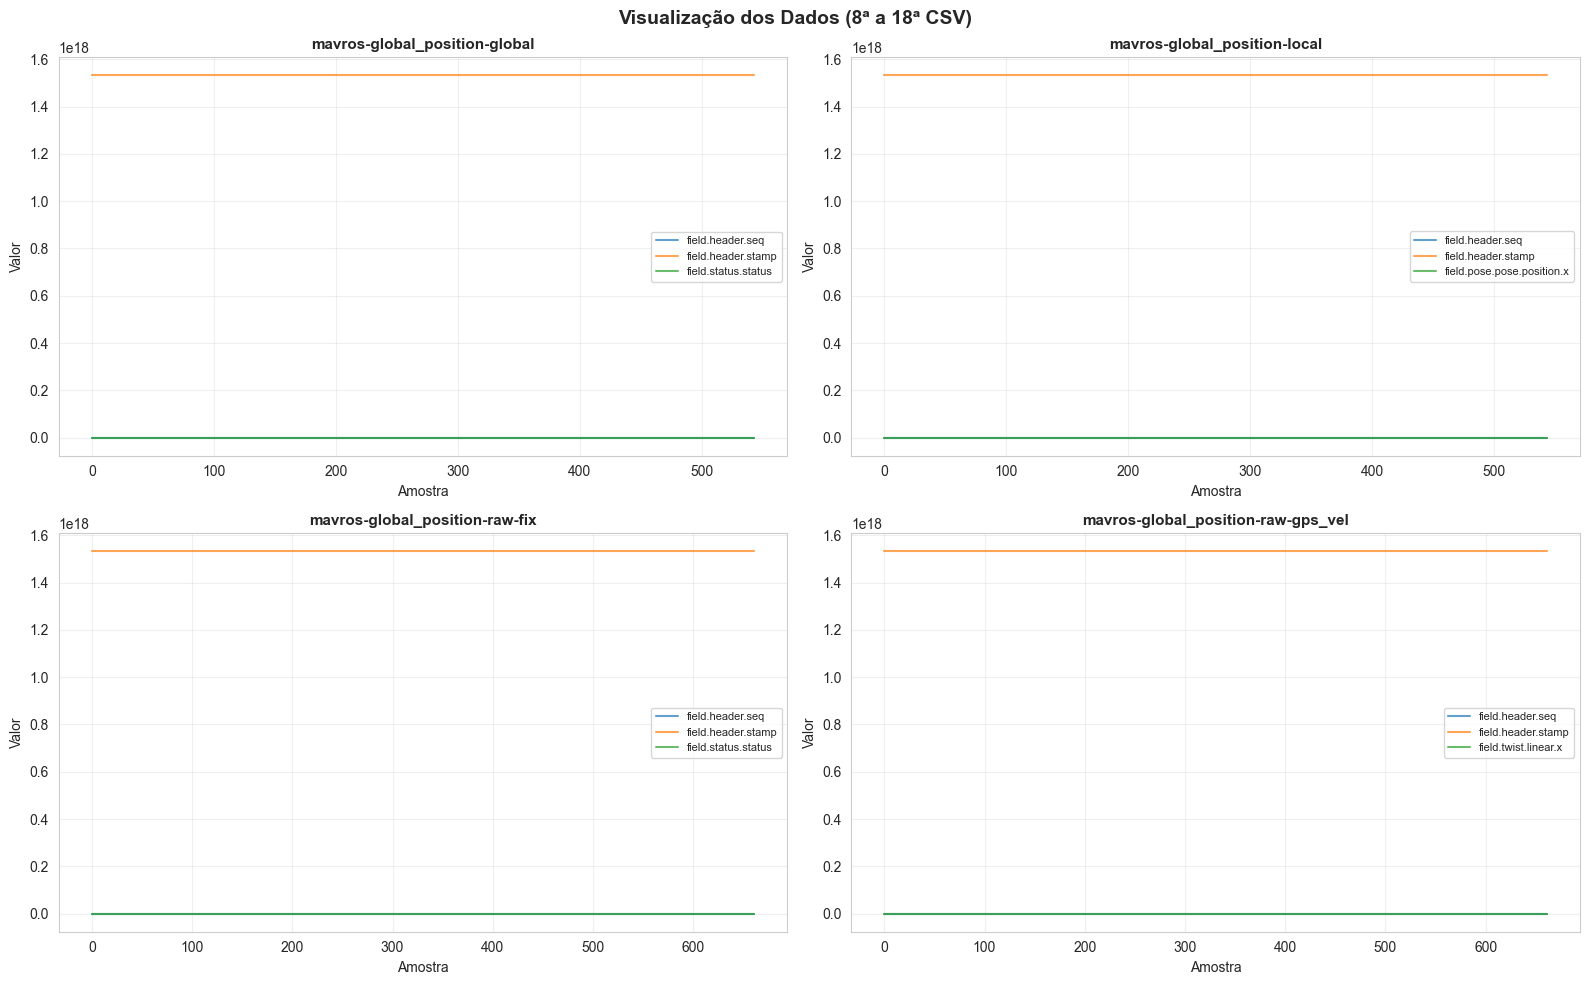

In [8]:
# Gráficos: Primeiros 4 Datasets
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Visualização dos Dados (8ª a 18ª CSV)', fontsize=14, fontweight='bold')

dataset_items = list(datasets_dict.items())[:4]

for idx, (ax, (name, df)) in enumerate(zip(axes.flatten(), dataset_items)):
    numeric_cols = df.select_dtypes(include=[np.number]).columns[:3]
    
    for col in numeric_cols:
        ax.plot(df[col], label=col, linewidth=1.5, alpha=0.7)
    
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Amostra')
    ax.set_ylabel('Valor')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

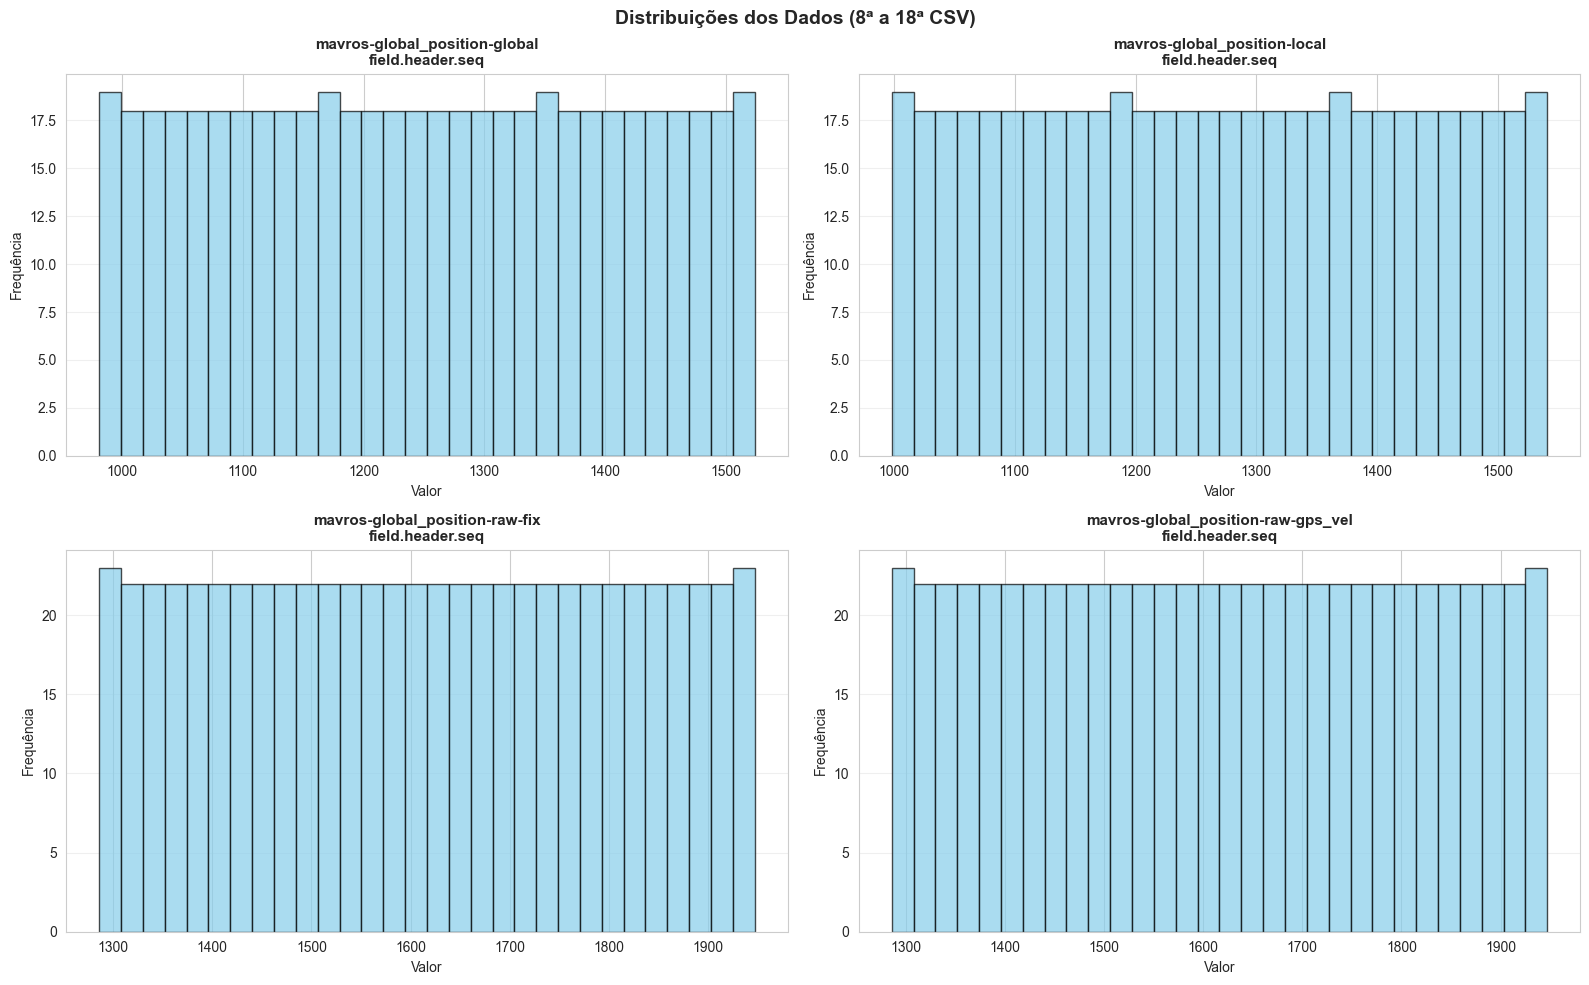

In [9]:
# Histogramas e Distribuições
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Distribuições dos Dados (8ª a 18ª CSV)', fontsize=14, fontweight='bold')

dataset_items = list(datasets_dict.items())[:4]

for ax, (name, df) in zip(axes.flatten(), dataset_items):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    if len(numeric_cols) > 0:
        data = df[numeric_cols[0]].dropna()
        ax.hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        ax.set_title(f'{name}\n{numeric_cols[0]}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Valor')
        ax.set_ylabel('Frequência')
        ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

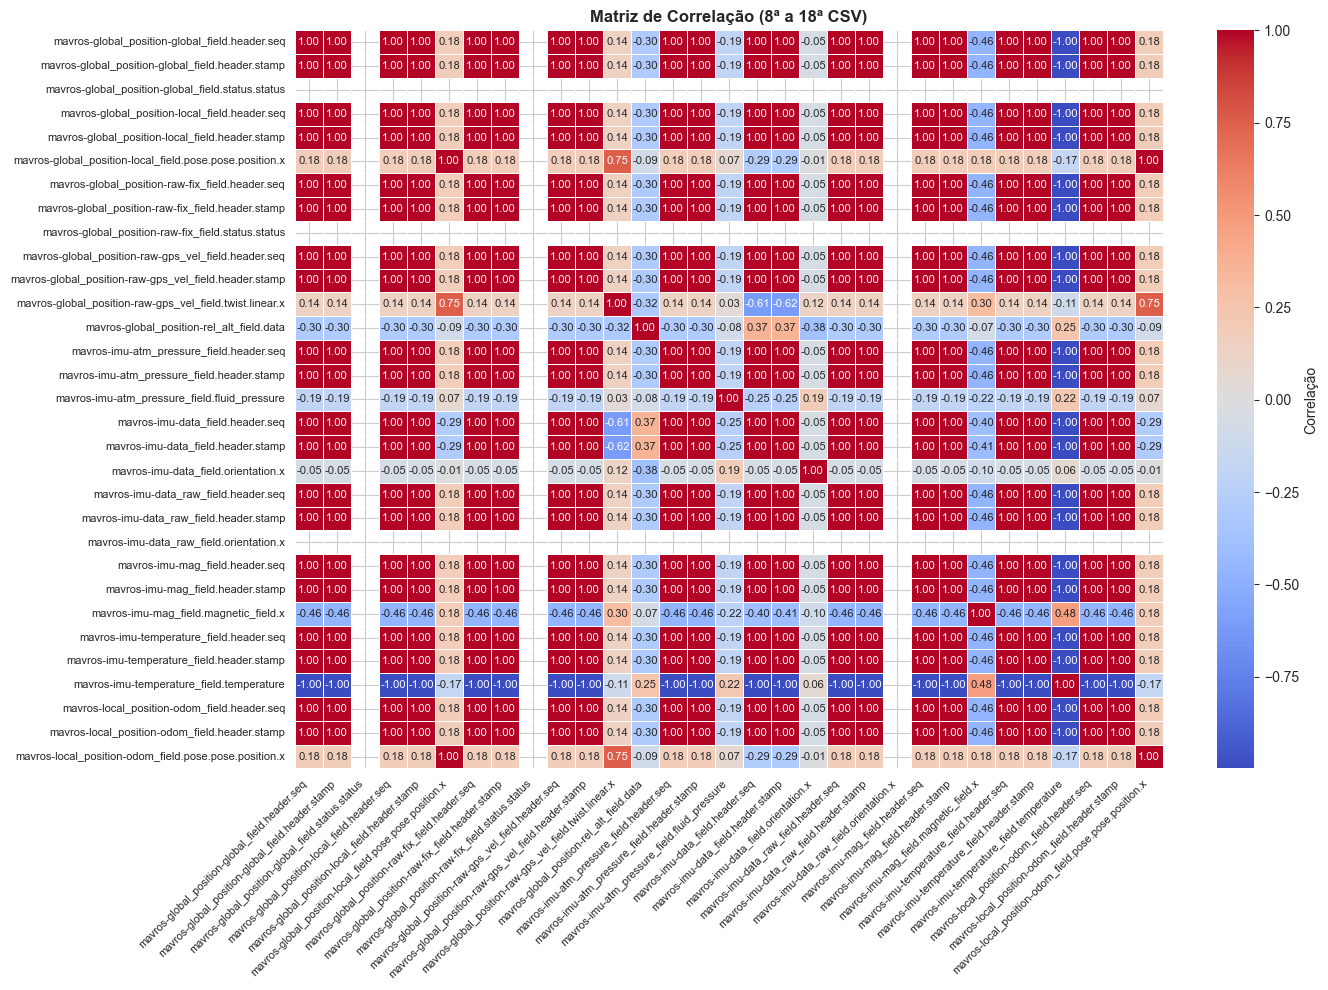

In [10]:
# Matriz de Correlação (Heatmap)
fig, ax = plt.subplots(figsize=(14, 10))

# Combinar dados numéricos de todos os datasets
combined_data = pd.DataFrame()

for name, df in datasets_dict.items():
    numeric_cols = df.select_dtypes(include=[np.number]).columns[:3]
    for col in numeric_cols:
        combined_data[f'{name}_{col}'] = df[col].reset_index(drop=True)

# Limitar ao tamanho mínimo comum
if not combined_data.empty:
    corr_matrix = combined_data.corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
                ax=ax, cbar_kws={'label': 'Correlação'}, linewidths=0.5, 
                annot_kws={'size': 8})
    ax.set_title('Matriz de Correlação (8ª a 18ª CSV)', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Sem dados numéricos para correlação")

## 6. Análise Avançada - Detecção de Anomalias e Tendências

DETECÇÃO DE ANOMALIAS (Z-score > 3)

mavros-global_position-global:
  field.altitude: 15 anomalias (2.76%)
  field.position_covariance0: 14 anomalias (2.57%)
  field.position_covariance4: 14 anomalias (2.57%)
  field.position_covariance8: 14 anomalias (2.57%)

mavros-global_position-local:
  field.pose.pose.position.z: 15 anomalias (2.76%)
  field.pose.covariance0: 14 anomalias (2.57%)
  field.pose.covariance7: 14 anomalias (2.57%)
  field.pose.covariance14: 14 anomalias (2.57%)
  field.pose.pose.orientation.y: 7 anomalias (1.29%)
  field.twist.twist.linear.z: 7 anomalias (1.29%)
  field.pose.pose.orientation.x: 6 anomalias (1.10%)

mavros-global_position-raw-fix:
  field.altitude: 20 anomalias (3.02%)
  field.position_covariance0: 18 anomalias (2.72%)
  field.position_covariance4: 18 anomalias (2.72%)
  field.position_covariance8: 18 anomalias (2.72%)

mavros-global_position-raw-gps_vel: Nenhuma anomalia detectada

mavros-global_position-rel_alt:
  field.data: 15 anomalias (2.76%)

ma

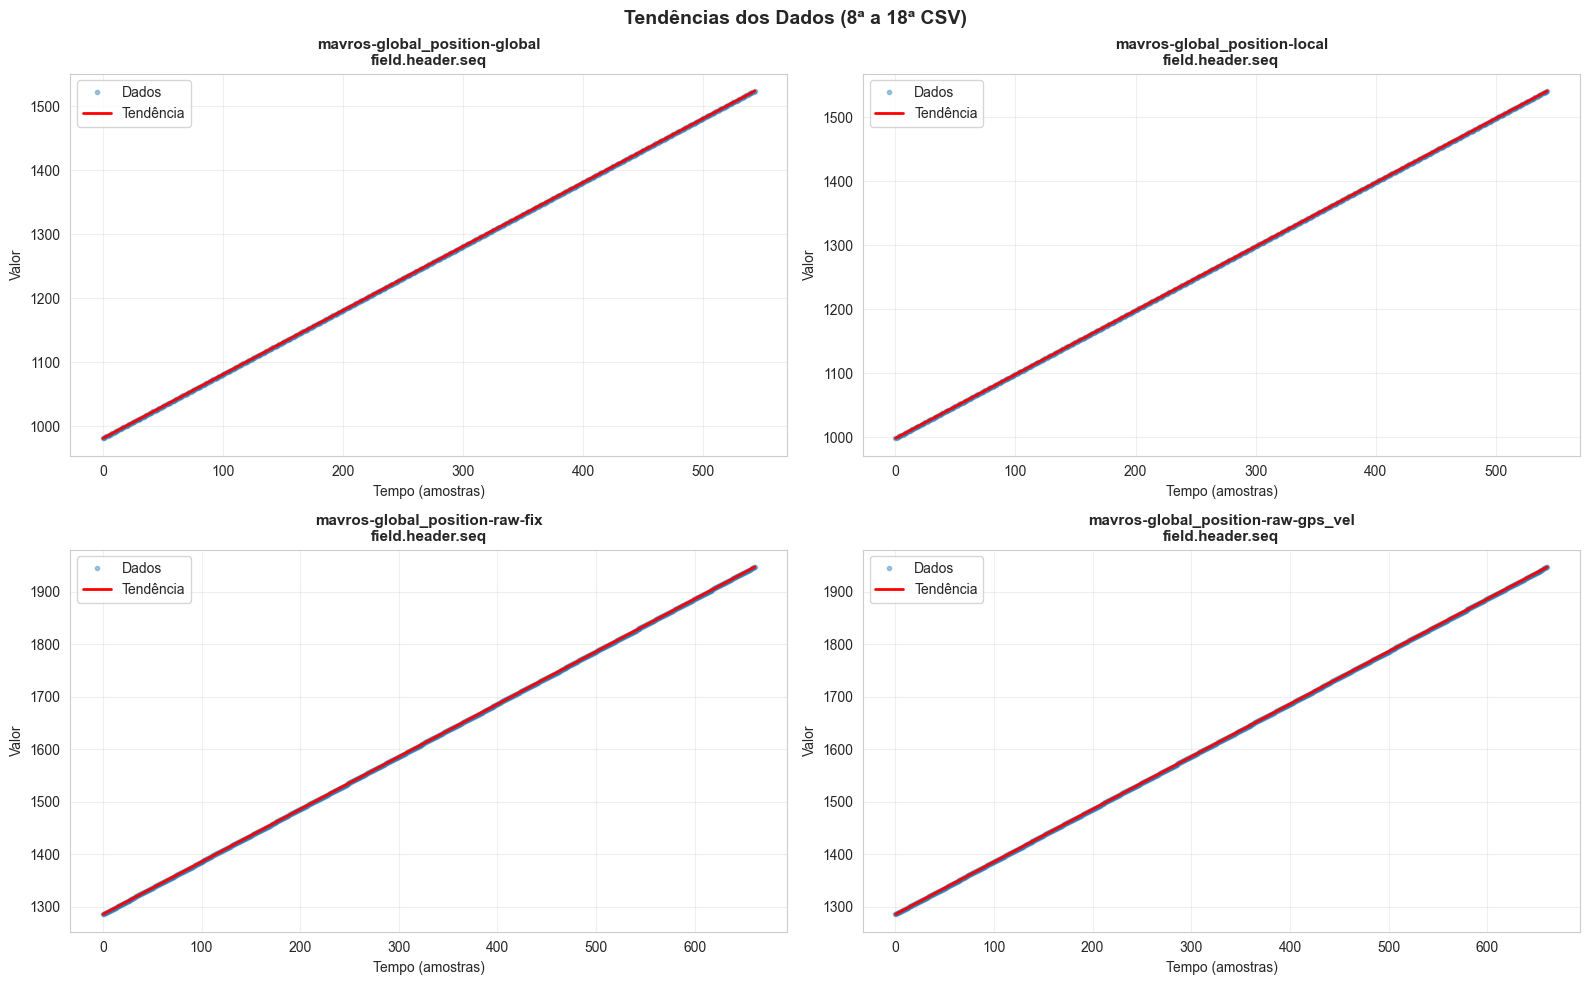

In [11]:
# Detecção de Anomalias
from scipy.stats import zscore

print("=" * 70)
print("DETECÇÃO DE ANOMALIAS (Z-score > 3)")
print("=" * 70)

def detect_anomalies(df, threshold=3):
    """Detecta anomalias usando Z-score"""
    anomalies = {}
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    for col in numeric_cols:
        try:
            z_scores = np.abs(zscore(df[col].dropna()))
            anomaly_indices = np.where(z_scores > threshold)[0]
            if len(anomaly_indices) > 0:
                anomalies[col] = len(anomaly_indices)
        except:
            pass
    
    return anomalies

# Detectar anomalias
for name, df in datasets_dict.items():
    anomalies = detect_anomalies(df)
    if anomalies:
        print(f"\n{name}:")
        for col, count in sorted(anomalies.items(), key=lambda x: x[1], reverse=True):
            pct = (count / len(df)) * 100
            print(f"  {col}: {count} anomalias ({pct:.2f}%)")
    else:
        print(f"\n{name}: Nenhuma anomalia detectada")

# Análise de Tendência
print("\n" + "=" * 70)
print("ANÁLISE DE TENDÊNCIA")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Tendências dos Dados (8ª a 18ª CSV)', fontsize=14, fontweight='bold')

dataset_items = list(datasets_dict.items())[:4]

for ax, (name, df) in zip(axes.flatten(), dataset_items):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    if len(numeric_cols) > 0:
        col = numeric_cols[0]
        x = np.arange(len(df))
        y = df[col].values
        
        try:
            z = np.polyfit(x, y, 1)
            p = np.poly1d(z)
            ax.plot(x, y, 'o', alpha=0.4, markersize=3, label='Dados')
            ax.plot(x, p(x), 'r-', linewidth=2, label='Tendência')
            ax.set_title(f'{name}\n{col}', fontsize=11, fontweight='bold')
            ax.set_xlabel('Tempo (amostras)')
            ax.set_ylabel('Valor')
            ax.legend()
            ax.grid(True, alpha=0.3)
        except:
            ax.text(0.5, 0.5, 'Erro ao plotar', ha='center', va='center')

plt.tight_layout()
plt.show()

In [12]:
# Resumo Final
print("\n" + "=" * 70)
print("RESUMO FINAL - ANÁLISE (8ª a 18ª CSV)")
print("=" * 70)

total_rows = sum(len(df) for df in datasets_dict.values())
total_cols = sum(df.shape[1] for df in datasets_dict.values())
total_numeric = sum(len(df.select_dtypes(include=[np.number]).columns) for df in datasets_dict.values())

print(f"""
📊 ESTATÍSTICAS GERAIS:
  • Total de datasets carregados: {len(datasets_dict)}
  • Total de linhas: {total_rows:,}
  • Total de colunas: {total_cols}
  • Colunas numéricas: {total_numeric}

📁 ARQUIVOS ANALISADOS (8ª a 18ª posição):
""")

for i, name in enumerate(datasets_dict.keys(), 8):
    shape = datasets_dict[name].shape
    print(f"  {i}. {name}: {shape}")

print(f"""
✅ PROCESSAMENTO CONCLUÍDO COM SUCESSO!

Próximos passos:
  1. Executar as células para visualizar os gráficos
  2. Analisar correlações entre sensores
  3. Identificar padrões de falha
  4. Comparar com datasets sem falha
""")


RESUMO FINAL - ANÁLISE (8ª a 18ª CSV)

📊 ESTATÍSTICAS GERAIS:
  • Total de datasets carregados: 11
  • Total de linhas: 9,122
  • Total de colunas: 340
  • Colunas numéricas: 317

📁 ARQUIVOS ANALISADOS (8ª a 18ª posição):

  8. mavros-global_position-global: (544, 19)
  9. mavros-global_position-local: (544, 90)
  10. mavros-global_position-raw-fix: (662, 19)
  11. mavros-global_position-raw-gps_vel: (662, 10)
  12. mavros-global_position-rel_alt: (544, 2)
  13. mavros-imu-atm_pressure: (1323, 6)
  14. mavros-imu-data: (328, 41)
  15. mavros-imu-data_raw: (1324, 41)
  16. mavros-imu-mag: (1324, 16)
  17. mavros-imu-temperature: (1323, 6)
  18. mavros-local_position-odom: (544, 90)

✅ PROCESSAMENTO CONCLUÍDO COM SUCESSO!

Próximos passos:
  1. Executar as células para visualizar os gráficos
  2. Analisar correlações entre sensores
  3. Identificar padrões de falha
  4. Comparar com datasets sem falha

